In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


# Part 1

In [154]:
df = pd.read_csv('/kaggle/input/datasets/abbas829/telco-customer-churn-dataset/Telco-Customer-Churn.csv')
df.head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [155]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

**customerID and gender has no extra relationship with telco customer churn and their services.**

In [156]:
df.drop(columns = ['customerID','gender'], axis=1, inplace=True)

In [157]:
df.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'],
      dtype='object')

In [158]:
df.shape

(7043, 19)

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7043 non-null   int64  
 1   Partner           7043 non-null   object 
 2   Dependents        7043 non-null   object 
 3   tenure            7043 non-null   int64  
 4   PhoneService      7043 non-null   object 
 5   MultipleLines     7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   OnlineBackup      7043 non-null   object 
 9   DeviceProtection  7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  StreamingMovies   7043 non-null   object 
 13  Contract          7043 non-null   object 
 14  PaperlessBilling  7043 non-null   object 
 15  PaymentMethod     7043 non-null   object 
 16  MonthlyCharges    7043 non-null   float64


In [160]:
df.isnull().sum()

SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Blank columns has filled by mode. TotalCharges is object type. so weve done it by mode.**

In [161]:
print((df == " ").sum())
print("="*40)
mode_value = df['TotalCharges'].replace(" ",np.nan).mode()[0]
print("Mode: ",mode_value)
print("="*40)
idx = df[df['TotalCharges']==" "].index
print("Index of Toaal Charges: ",idx)
df.loc[idx, 'TotalCharges']= mode_value

SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
Mode:  20.2
Index of Toaal Charges:  Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')


In [162]:
print((df["TotalCharges"] == " ").sum())

0


# Important feature visualize

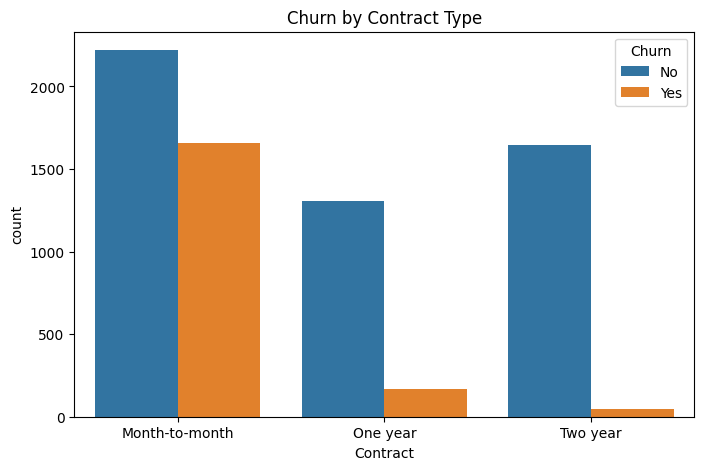

In [163]:
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")

plt.show()

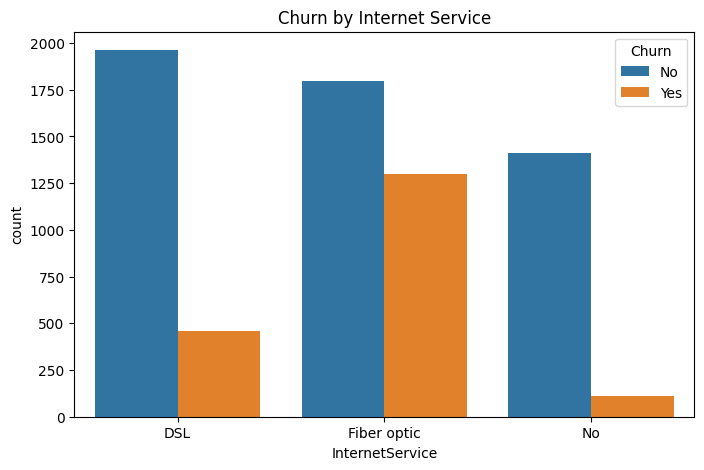

In [164]:
plt.figure(figsize=(8,5))

sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Churn by Internet Service")

plt.show()

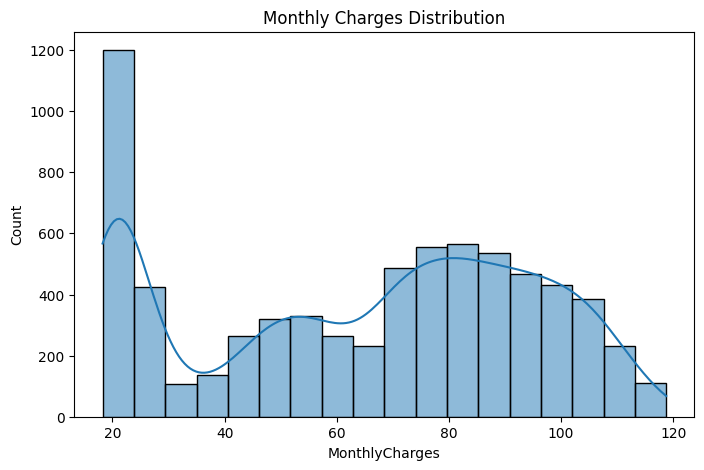

In [165]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], kde=True)

plt.title("Monthly Charges Distribution")

plt.show()

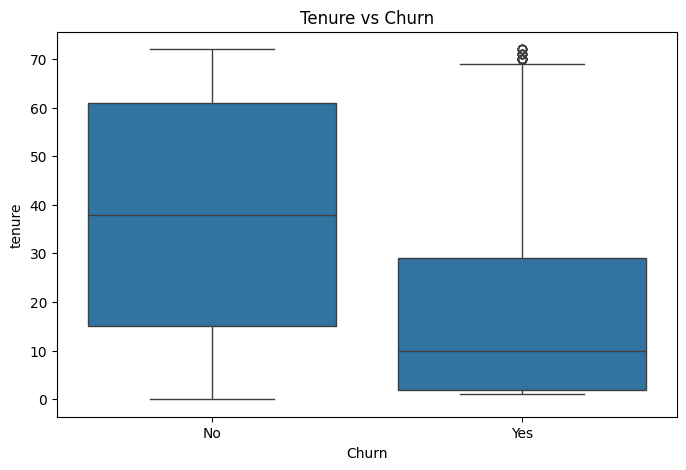

In [166]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")

plt.show()

# **now TotalCharges converted categorical to numerical**

In [167]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [168]:
print("Before Skew: ",df['TotalCharges'].skew())
df['TotalCharges'] = np.sqrt(df['TotalCharges'])
print("After Skew: ",df['TotalCharges'].skew())

Before Skew:  0.9632750433821938
After Skew:  0.30940821823467035


In [169]:
df.select_dtypes(include='object').columns

Index(['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

# **Partner was object and converted into numeric**

In [170]:
print(df['Partner'].value_counts())
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})

Partner
No     3641
Yes    3402
Name: count, dtype: int64


In [171]:
print(df['Dependents'].value_counts())
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})

Dependents
No     4933
Yes    2110
Name: count, dtype: int64


In [172]:
print(df['PhoneService'].value_counts())
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})

PhoneService
Yes    6361
No      682
Name: count, dtype: int64


In [173]:
print(df['MultipleLines'].value_counts())
df = pd.get_dummies(columns = ['MultipleLines'],data=df,drop_first=True)

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


In [174]:
result={}
for i in df.columns:
    if df[i].dtypes=='object':
        result[i]=df[i].value_counts()
        print(result[i])
        print("="*40)

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64
StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
PaperlessBilling
Yes    4171
No     2872
Name: co

In [175]:
print(df['PaperlessBilling'].value_counts())
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes':1,'No':0})

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64


In [176]:
df = pd.get_dummies(columns=['InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
                            ,'Contract','PaymentMethod'],data=df,drop_first=True)

In [177]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Statistical Summary

In [178]:
df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,40.944135,0.265370
std,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,24.564799,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,4.335897,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,19.963717,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,37.343674,0.000000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,61.535352,1.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,93.192274,1.000000


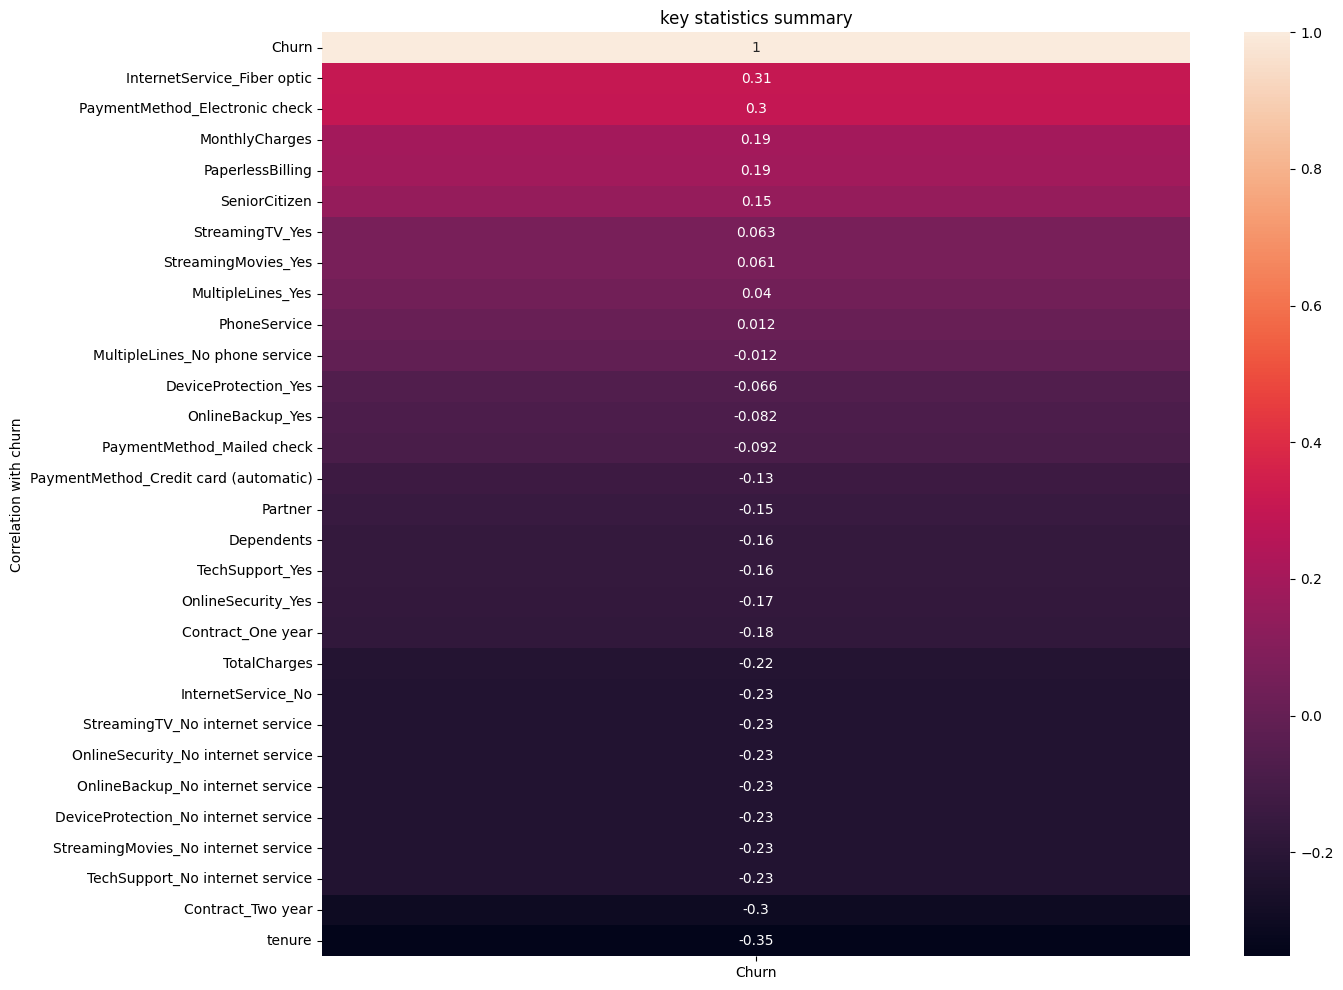

In [179]:
plt.figure(figsize=(14,12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix['Churn'].sort_values(ascending=False).to_frame(), annot=True)
plt.title("key statistics summary")
plt.ylabel('Correlation with churn')
plt.show()

In [180]:
X = df.drop('Churn', axis=1)
y=df['Churn']

In [181]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Scalling And Converted it to DataFrame

In [182]:
scale = StandardScaler()
X_train_scaled= scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

In [183]:
X_train = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)
X_test = pd.DataFrame(
    X_test_scaled,
    columns = X_test.columns,
    index = X_test.index
)

# Part 2

****A .Logistic Regression is a classification algorithm. The model combines all the features using Linear Equation.  But it has no limited size. We want a limited probability between 0 to 1.Thats where sigmoid function comes in. The sigmoid function convert any number between 0 to 1.****

In [184]:
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8126330731014905
Precision: 0.6798679867986799
Recall   : 0.5522788203753352
F1 Score : 0.6094674556213018


**B. KNN means K-Nearest Neighbors. KNN does not actually learn mathmetical pattern during training. Most algorithm learn pattern first then make prediction. But knn simply stores the training data, then wait untill prediction. And k must be odd numbers.**

In [185]:
k_values = [3, 5, 7, 9]

results = []

for i in k_values:

    model_k = KNeighborsClassifier(n_neighbors= i)

    model_k.fit(X_train, y_train)

    y_pred_k = model_k.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred_k)

    results.append({
        "K": i,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

results_df

,K,Accuracy
0,3,0.754436
1,5,0.765082
2,7,0.789212
3,9,0.792761


> The performance of KNN changes with the value of K. A small K value makes the model more sensitive to individual neighboring points and noise, while a larger K value produces smoother and more stable predictions but may underfit. Feature scaling is important for KNN because the algorithm relies on distance calculations. Without scaling, features with larger numerical ranges can dominate the distance calculation. Therefore, the scaled features are more appropriate for KNN.

**C. A decision tree is a classification algorithm that splits data by applying a series of questions or conditions.**

In [186]:
leaf_values = [5, 10, 20]
depths = [5, 7, 10]

results = []
for leaf in leaf_values:
    for depth in depths:                     
        model_3 = DecisionTreeClassifier(
            min_samples_leaf=leaf,
            max_depth=depth,                  
            random_state=42
        )
        model_3.fit(X_train, y_train)
        test_pred = model_3.predict(X_test)
        results.append({
            "min_samples_leaf": leaf,
            "max_depth": depth,
            "Train Accuracy": accuracy_score(y_test, test_pred),
            "Test Accuracy": accuracy_score(y_test, test_pred)
        })

leaf_results = pd.DataFrame(results)
leaf_results

,min_samples_leaf,max_depth,Train Accuracy,Test Accuracy
0,5,5,0.807665,0.807665
1,5,7,0.793471,0.793471
2,5,10,0.770759,0.770759
3,10,5,0.807665,0.807665
4,10,7,0.798439,0.798439
5,10,10,0.785664,0.785664
6,20,5,0.807665,0.807665
7,20,7,0.801987,0.801987
8,20,10,0.799148,0.799148


> Best combo: min_samples_leaf=10, max_depth=7 → 79.6% test accuracy, with train (81.6%) staying close to test — a healthy, non-overfit gap.


**D. Random Forest is a combination of multiple decision trees.It generates multiple tree predictions and produces a final prediction based on a majority vote.For this reason, a Random Forest is generally more robust than a single Decision Tree and is less prone to overfitting.**


In [187]:
results = []
best_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    max_features="sqrt",
    random_state=42
)

best_model.fit(X_train, y_train)

y_pred_R = best_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred_R)
precision = precision_score(y_test, y_pred_R)
recall = recall_score(y_test, y_pred_R)
f1 = f1_score(y_test, y_pred_R)

results.append({
    "n_estimators": best_model.n_estimators,
    "max_depth": best_model.max_depth,
    "max_features": best_model.max_features,
    "Accuracy": accuracy,

})

results_df = pd.DataFrame(results)
results_df

,n_estimators,max_depth,max_features,Accuracy
0,100,10,sqrt,0.811214


In [188]:
comparison_results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, test_pred),
        accuracy_score(y_test, y_pred_R)
    ],
    "Precision": [
        precision_score(y_test, test_pred),
        precision_score(y_test, y_pred_R)
    ],
    "Recall": [
        recall_score(y_test, test_pred),
        recall_score(y_test, y_pred_R)
    ],
    "F1 Score": [
        f1_score(y_test, test_pred),
        f1_score(y_test, y_pred_R)
    ]
})

comparison_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.799148,0.651007,0.520107,0.578241
1,Random Forest,0.811214,0.689046,0.522788,0.594512


> So we can see , Random Forest perform better than Decission tree

# Part 3

Logistic Regression
TN: 939
FP: 97
FN: 167
TP: 206
Accuracy : 0.8126330731014905
Precision: 0.6798679867986799
Recall   : 0.5522788203753352
F1 Score : 0.6094674556213018


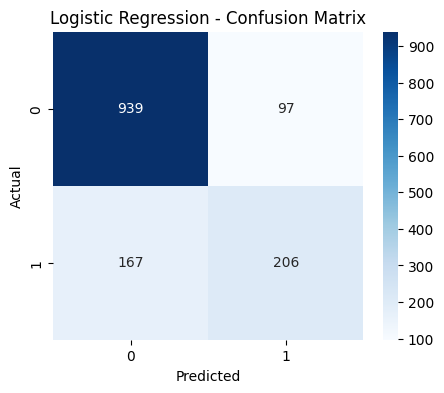

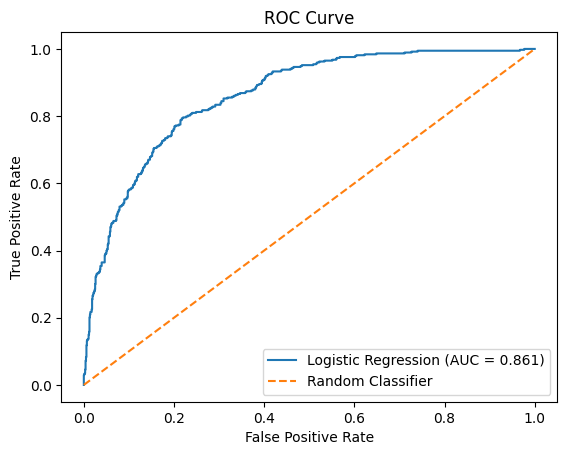

KNN
TN: 910
FP: 126
FN: 166
TP: 207
Accuracy : 0.7927608232789212
Precision: 0.6216216216216216
Recall   : 0.5549597855227882
F1 Score : 0.5864022662889519


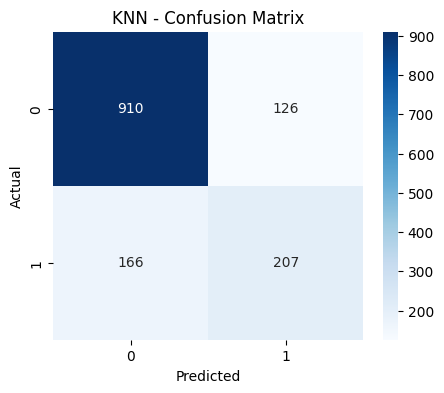

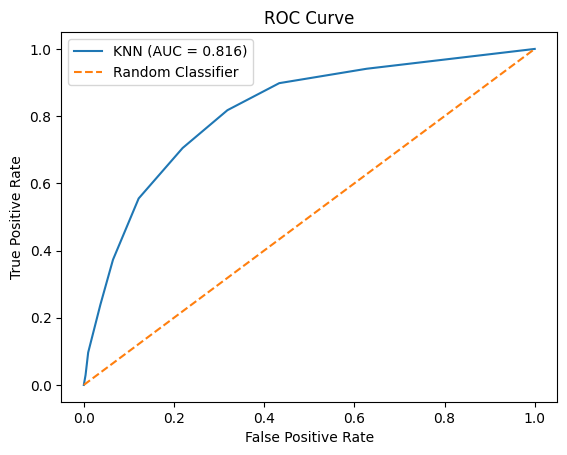

Decision Tree
TN: 932
FP: 104
FN: 179
TP: 194
Accuracy : 0.7991483321504613
Precision: 0.6510067114093959
Recall   : 0.5201072386058981
F1 Score : 0.5782414307004471


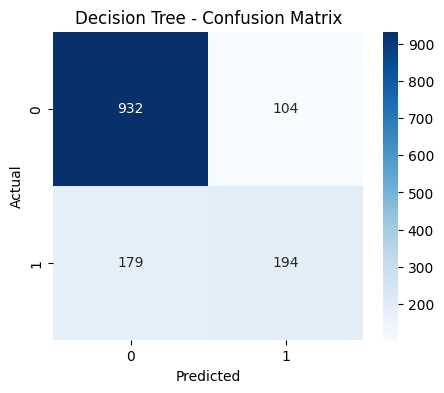

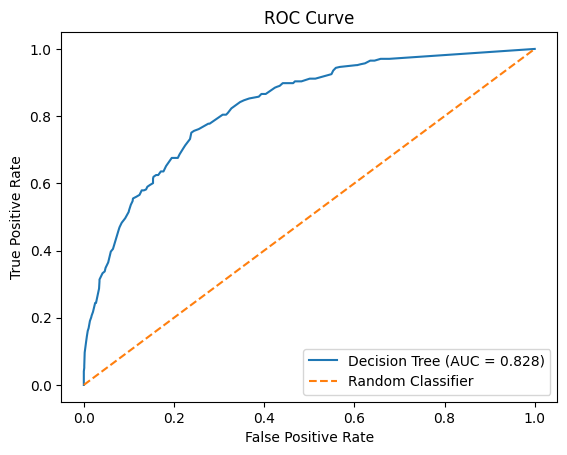

Random Forest
TN: 948
FP: 88
FN: 178
TP: 195
Accuracy : 0.8112136266855926
Precision: 0.6890459363957597
Recall   : 0.5227882037533512
F1 Score : 0.5945121951219512


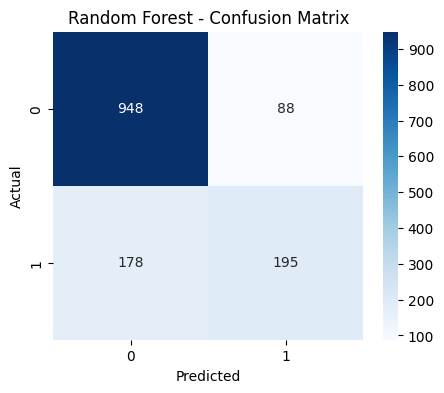

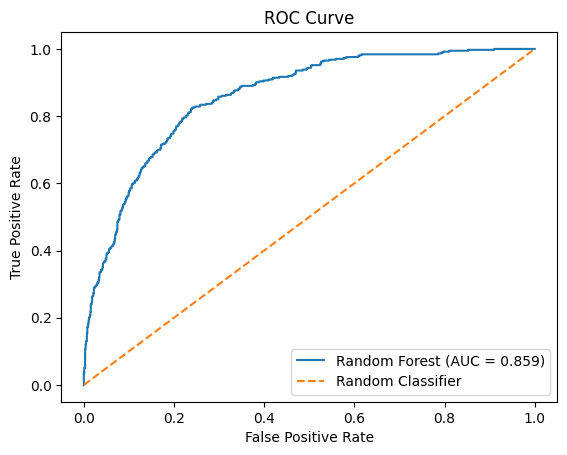

In [189]:


model_dict = {
    "Logistic Regression": model_lr,
    "KNN": model_k,
    "Decision Tree": model_3,
    "Random Forest": best_model
}

for name, model_dict in model_dict.items():
    y_pred = model_dict.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print("=" * 50)
    print(name)
    print("=" * 50)
    print("TN:", tn)
    print("FP:", fp)
    print("FN:", fn)
    print("TP:", tp)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show() 


#For roc, auc curve
    y_prob = model_dict.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

    plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")

    plt.legend()
    plt.show()

In [190]:


model_dict = {
    "Logistic Regression": model_lr,
    "KNN": model_k,
    "Decision Tree": model_3,
    "Random Forest": best_model
}

results = []
for name, model in model_dict.items():          
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    
    results.append({
        "Model": name,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

summary_df = pd.DataFrame(results)
print("Comparing summary table")
summary_df

Comparing summary table


,Model,TN,FP,FN,TP,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,939,97,167,206,0.8126,0.6799,0.5523,0.6095,0.8607
1,KNN,910,126,166,207,0.7928,0.6216,0.5550,0.5864,0.8156
2,Decision Tree,932,104,179,194,0.7991,0.6510,0.5201,0.5782,0.8277
3,Random Forest,948,88,178,195,0.8112,0.6890,0.5228,0.5945,0.8590


# Discuss:

Which model performs best overall?
> Among the four models, Random Forest performs best overall because it provides a good balance between accuracy, precision, recall, F1 score, and ROC-AUC. It is able to capture more complex patterns in customer behavior by combining multiple decision trees. Therefore, Random Forest is selected as the best-performing model for predicting customer churn.

Which metric (precision or recall) is more important for this business problem?
> Recall is more important for the Telco customer churn problem because the company wants to identify as many potential churn customers as possible. A false negative means a customer who is actually likely to churn is predicted as a non-churn customer, causing the company to miss an opportunity to take retention actions. Therefore, a higher recall is generally preferred, although precision should also be considered to avoid wasting resources on customers who are unlikely to churn.

Trade-offs between model interpretability and performance.
> There is also a trade-off between interpretability and performance. A Decision Tree is easier to understand and explain because its decisions can be represented as a sequence of simple rules. Random Forest is less interpretable because it combines many decision trees, but it can provide better and more stable predictive performance. Therefore, the final model should be chosen by balancing predictive performance with the level of interpretability required by the business.

# Part 4

>  This project demonstrates how machine learning can be used to predict customer churn in the telecommunications industry. Exploratory analysis and feature importance revealed that factors such as contract type, tenure, monthly charges, and service-related features can play an important role in churn prediction. Several classification models, including Logistic Regression, KNN, Decision Tree, and Random Forest, were trained and evaluated using multiple metrics. The final model should be selected based on its ability to identify potential churn customers while maintaining an acceptable level of precision. For business purposes, recall is particularly important because failing to identify a customer who is likely to churn can result in lost revenue and missed retention opportunities. Overall, a well-tuned Random Forest model can be a strong choice when predictive performance is prioritized, while simpler models such as Logistic Regression or Decision Tree may be preferred when interpretability is more important.